## Análisis y Procesamiento de Señales, 2°C 2026
### Universidad Nacional de San Martín
#### Iara Alvarez Costa

# Tarea Semanal N°0
Se nos pide programar una función que genere señales senoidales y que permita parametrizar:

- la amplitud máxima de la senoidal (volts)
- su valor medio (volts)
- la frecuencia (Hz)
- la fase (radianes)
- la cantidad de muestras digitalizada por el ADC (# muestras)
- la frecuencia de muestreo del ADC.

## Resolución:

In [1]:
# Importación de módulos

import numpy as np
import matplotlib.pyplot as plt


In [52]:
# Definicion de ctes experimentales

fs = 1000 #Frecuencia muestreo (Hz) 
N = 1000 #Nro muestras
vmax = 1.5 #Amp max
dc = 0 #Offset
ff = 2 #Frecuencia sinusoidal (Hz)
ph = 0 #Fase sinusoidal [rad]


In [53]:
# Funciones

def gen_sin (vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):

    tt = np.arange(0, stop=N/fs, step=1/fs)#genero un vector de valores de 0 a N/fs segundos a intervalos de 1/fs
    xx = dc + vmax * np.sin (2 * np.pi * ff * tt + ph)
    
    return tt, xx

In [54]:
# Invoco la función
tt, xx = gen_sin( vmax, dc, ff, ph, N, fs) 


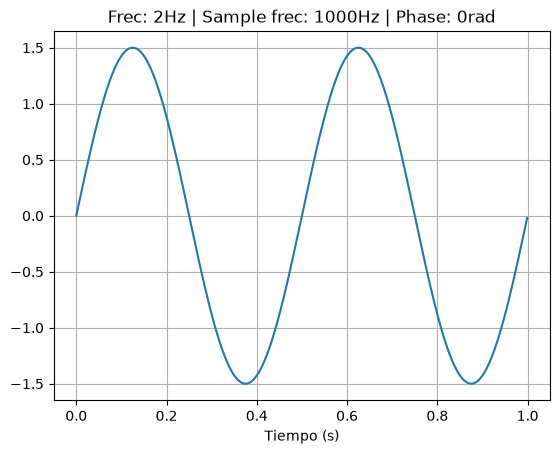

In [55]:
#Grafico
plt.plot(tt,xx)
plt.xlabel("Tiempo (s)")
plt.title("Frec: " + str(ff) + "Hz | Sample frec: " + str(fs) + "Hz | Phase: " + str(ph) + "rad")
plt.grid()
plt.show()

Arriba se muestra el gráfico para una frecuencia ff de prueba igual a 2 Hz. Ahora me interesa ver el comportamiento de la función para ff=fs/2, la frecuencia de Nyquist:

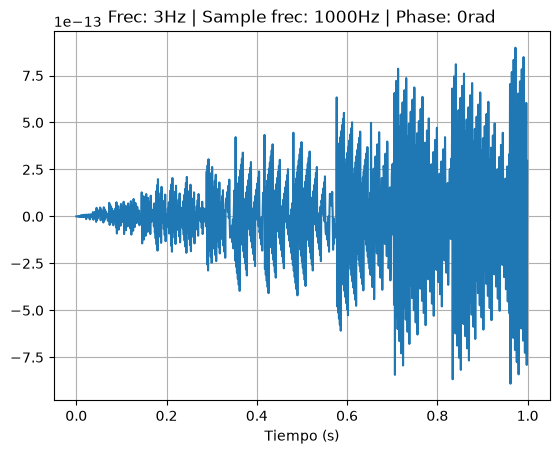

In [50]:
tt, xx = gen_sin( vmax, dc, 500, ph, N, fs) 

plt.plot(tt,xx)
plt.xlabel("Tiempo (s)")
plt.title("Frec: " + str(ff) + "Hz | Sample frec: " + str(fs) + "Hz | Phase: " + str(ph) + "rad")
plt.grid()
plt.show()

En este caso, ff=500 Hz, lo que significa que x[n]=sin(2π⋅500⋅1000n​) me queda x[n]=sin(nπ), que devuelve valores ~0 para todo valor de n, lo cual se aprecia al notar la indicación en la esquina superior izquierda del gráfico; significa que se están graficando valores del orden de 1e-13.

Observación menor: Es interesante observar la periodicidad de la señal alrededor de la frecuencia de muestreo. Dos señales distanciadas un valor entero de la frecuencia de muestreo devolverán los mismos valores. Ejemplifico con ff=1 y ff=1001:

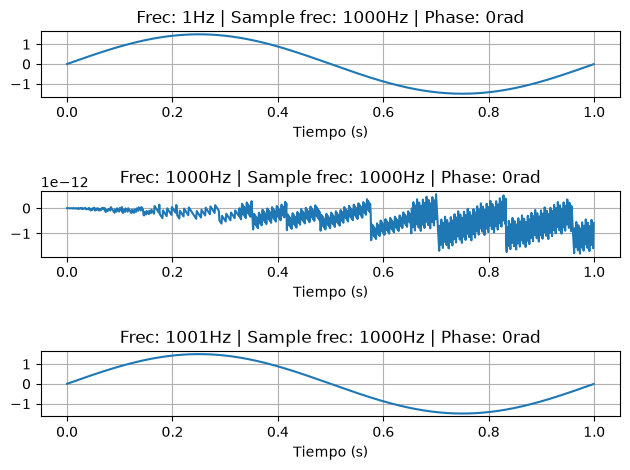

In [59]:
ff1=1
ff2=1000
ff3=1001

#Defino un nuevo set de vectores con diferentes ff
tt1, xx1 = gen_sin( vmax, dc, ff1, ph, N, fs) 
tt2, xx2 = gen_sin( vmax, dc, ff2, ph, N, fs) 
tt3, xx3 = gen_sin( vmax, dc, ff3, ph, N, fs) 

# Gráfico 1 (arriba)
plt.subplot(3, 1, 1)
plt.plot(tt1, xx1)
plt.title("Frec: " + str(ff1) + "Hz | Sample frec: " + str(fs) + "Hz | Phase: " + str(ph) + "rad")
plt.xlabel("Tiempo (s)")
plt.grid()

# Gráfico 2 
plt.subplot(3, 1, 2)
plt.plot(tt2, xx2)
plt.title("Frec: " + str(ff2) + "Hz | Sample frec: " + str(fs) + "Hz | Phase: " + str(ph) + "rad")
plt.xlabel("Tiempo (s)")
plt.grid()

# Gráfico 3 (abajo)
plt.subplot(3, 1, 3)
plt.plot(tt3, xx3)
plt.title("Frec: " + str(ff3) + "Hz | Sample frec: " + str(fs) + "Hz | Phase: " + str(ph) + "rad")
plt.xlabel("Tiempo (s)")
plt.grid()


plt.tight_layout()
plt.show()